In [7]:
# -*- coding:utf-8 _*-
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.offline as py

from tqdm import tqdm
import time
import gc
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import *
from sklearn.model_selection import *
from sklearn.preprocessing import StandardScaler, LabelEncoder
import optuna
from optuna import Trial
import lightgbm as lgb

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format','{:}'.format)

- **作者**：东哥起飞

- **课程**：[**《100天成为风控专家》**](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2ZAoFMNREbOv3DutKsoIi9Vlfky)

# **一、导入数据**

In [9]:
# 导入数据
# 数据已进行初步IV>0.1的筛选处理
df = pd.read_csv('feature_data.csv')
df.shape

(155590, 260)

In [10]:
df.head(2)

,lmt,bankCard_first6_loanProduct_encoder,bankCard_last3_loanProduct_encoder,dist_last2_loanProduct_count,bankCard_first6_loanProduct_count,bankCard_last3_loanProduct_count,dist_last2_loanProduct_encoder,loanProduct_lmt_mean,loanProduct_lmt_max,loanProduct_lmt_std,loanProduct_age_mean,loanProduct_age_median,loanProduct_age_max,loanProduct_age_std,loanProduct,loanProduct_lmt_median,loanProduct_lmt_min,unpayOtherLoan,bankCard_last3_edu_encoder,bankCard_first6_basicLevel_encoder,bankCard_first6_lmt_std,bankCard_first6_edu_count,bankCard_first6_edu_encoder,bankCard_last3_lmt_max,bankCard_last3_basicLevel_encoder,bankCard_last3_lmt_std,bankCard_last3_age_mean,bankCard_first6,bankCard_last3_lmt_mean,bankCard_first6_lmt_max,bankCard_first6_lmt_median,bankCard_last3_basicLevel_count,bankCard_last3_edu_count,bankCard_last3_lmt_median,bankCard_last3,bankCard_last3_age_max,bankCard_first6_age_std,bankCard_first6_age_max,bankCard_first6_lmt_mean,bankCard_last3_age_median,bankCard_first6_age_mean,bankCard_last3_lmt_min,bankCard_first6_lmt_min,bankCard_last3_age_std,bankCard_mean_last_1,bankCard_missing,x_46,linkRela_age_mean,linkRela_age_median,linkRela_lmt_mean,linkRela_lmt_std,linkRela,certId_first2_loanProduct_count,linkRela_age_std,bankCard_first6_basicLevel_count,linkRela_lmt_median,residentAddr_middle2_loanProduct_encoder,bankCard_first6_age_min,bankCard_first6_age_median,residentAddr_middle2_basicLevel_encoder,residentAddr_middle2_loanProduct_count,residentAddr_last2_loanProduct_count,residentAddr_first2_basicLevel_encoder,residentAddr_last2_loanProduct_encoder,residentAddr_first2_loanProduct_encoder,certId_last2_loanProduct_count,residentAddr_middle2_lmt_std,residentAddr_middle2_edu_encoder,residentAddr_middle2_lmt_mean,residentAddr_middle2_age_mean,residentAddr_first2_loanProduct_count,residentAddr_middle2_basicLevel_count,dist_last2_edu_count,residentAddr_first2_edu_encoder,residentAddr_middle2_age_std,residentAddr_first2,residentAddr_middle2_edu_count,dist_middle2_loanProduct_count,dist_middle2_loanProduct_encoder,residentAddr_middle2,residentAddr_first2_basicLevel_count,residentAddr_last2_basicLevel_count,residentAddr_middle2_lmt_median,residentAddr_last2_lmt_mean,residentAddr_mean_last_1,residentAddr_last2_basicLevel_encoder,residentAddr_last2_lmt_std,residentAddr_last2_age_mean,residentAddr_last2_edu_count,residentAddr_first2_lmt_median,job_age_mean,residentAddr_first2_age_mean,dist_first2_loanProduct_count,residentAddr_first1,residentAddr_middle2_lmt_max,job_age_std,residentAddr_last2_lmt_median,residentAddr_last2_edu_encoder,residentAddr_first2_edu_count,residentAddr_last2_age_std,residentAddr_last2,residentAddr_first2_lmt_std,residentAddr_last2_lmt_max,dist_last2_edu_encoder,residentAddr_first2_age_std,job_lmt_median,linkRela_lmt_max,residentAddr_first2_lmt_mean,certId_middle2_loanProduct_count,linkRela_lmt_min,linkRela_age_max,bankCard_last3_age_min,dist_last2_basicLevel_encoder,dist_last2_age_mean,setupHour_weekday_encoder,dist_last2_age_std,certId_dist_ratio,dist_last2_lmt_mean,dist_first2_loanProduct_encoder,residentAddr_missing,dist_last2,certId_first2_edu_count,dist_last2_lmt_median,certId_first2_loanProduct_encoder,setupHour_weekday_count,job_lmt_std,dist_last2_lmt_max,loanProduct_age_min,dist_last2_age_max,job,dist_last2_lmt_std,certId_first2_lmt_mean,dist_last2_basicLevel_count,dist_last2_lmt_min,certId_first2_basicLevel_count,ID,job_lmt_mean,x_50,dist_last2_age_median,residentAddr_first2_lmt_max,certId_first2_lmt_median,linkRela_age_min,job_age_median,dist_mean_last_1,x_68,certId_first2_basicLevel_encoder,dist32_diff_cnt,dist22_diff_cnt,residentAddr_last2_age_median,residentAddr_middle2_age_median,residentAddr_first2_age_median,job_age_max,certId_first2_age_mean,setupHour,certId_first2_edu_encoder,certId_last2_loanProduct_encoder,certId_first2_age_std,isNew,x_72,certId_first2,setupHour_age_std,certId_first2_lmt_std,setupHour_lmt_std,setupHour_age_mean,dist_middle2_basicLevel_encoder,dist_first2_basicLevel_count,x_

In [11]:
# 根据标签划分训练集和测试集
train = df[df['target'].isnull()==False]
test = df[df['target'].isnull()==True]
print(train.shape)
print(test.shape)

(132029, 260)
(23561, 260)


In [13]:
# 对训练集划分训练样本X和标签Y
features = df.columns.difference(['target']).tolist()
X = train[features].values
y = train['target'].astype('int32')
test_data = test[features].values
print(X.shape)
print(y.shape)

(132029, 259)
(132029,)


除了target以外，其余均是已经加工好的数值型变量，共259个。

# **二、调参**

In [68]:
def fit_lgbm_with_pruning(trial, train, val, devices=(-1,), seed=42, cat_features=None, num_rounds=200):
    """
    训练LightGBM模型
    """
    X_train, y_train = train
    X_valid, y_valid = val
    metric = 'auc'
    params = {
        'objective': 'binary',
        "boosting": "gbdt",
        'num_leaves': trial.suggest_int('num_leaves', 2, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.05, 0.2),
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 0.1, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 0.1, 10.0),
        "bagging_freq": trial.suggest_int('bagging_freq',2,10),
        "bagging_fraction": trial.suggest_uniform('bagging_fraction', 0.5, 1.0),
        "feature_fraction": trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth',2,4),
        'min_sum_hessian_in_leaf ': trial.suggest_int('min_sum_hessian_in_leaf',2,5),
        'min_gain_to_split': trial.suggest_int('min_gain_to_split',2,10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf',500,5000),
        'max_bin': trial.suggest_int('max_bin',2,30),
        "metric": metric,
        "verbosity": -1,
    }
    device = devices[0]
    if device == -1:
        # use cpu
        pass
    else:
        # use gpu
        print(f'using gpu device_id {device}...')
        params.update({'device': 'gpu', 'gpu_device_id': device})

    params['seed'] = seed

    early_stop = 100
    verbose_eval = 100

    d_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
    d_valid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=cat_features)
    watchlist = [d_train, d_valid]

    # 添加callback剪枝    
    pruning_callback = optuna.integration.LightGBMPruningCallback(trial, 'auc', valid_name='valid_1')
    print('training LGB:')
    model = lgb.train(params,
                      train_set=d_train,
                      num_boost_round=num_rounds,
                      valid_sets=watchlist,
                      verbose_eval=verbose_eval,
                      early_stopping_rounds=early_stop,
                      callbacks=[pruning_callback])

    # 预测
    y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)

    print('best_score', model.best_score)
    log = {'train/acu': model.best_score['training']['auc'],
           'valid/auc': model.best_score['valid_1']['auc']}
    return model, y_pred_valid, log


def objective_with_prune(trial: Trial, fast_check=False):
    """
    目标函数
    """
    folds = 5
    seed = 42
    shuffle = True
    kf = StratifiedKFold(n_splits=folds, shuffle=shuffle, random_state=seed) # 5折Kfold

    X_train, y_train = X, y
    y_valid_pred_total = np.zeros(X_train.shape[0])
    gc.collect()

    models0 = [] # 模型对象列表
    valid_score = 0 
    
    # 5折交叉验证
    for train_idx, valid_idx in kf.split(X_train, y_train):
        train_data = X_train[train_idx, :], y_train[train_idx]
        valid_data = X_train[valid_idx, :], y_train[valid_idx]

        print('train', len(train_idx), 'valid', len(valid_idx))
        model, y_pred_valid, log = fit_lgbm_with_pruning(trial, train_data,
                                                         valid_data,
                                                         num_rounds=200)
        y_valid_pred_total[valid_idx] = y_pred_valid
        models0.append(model)
        gc.collect()
        valid_score += log["valid/auc"] 
        if fast_check:
            break
    valid_score /= len(models0)
    return valid_score

study = optuna.create_study(pruner=optuna.pruners.MedianPruner(n_warmup_steps=5), direction="maximize")
study.optimize(objective_with_prune, n_trials=50)

[I 2024-01-30 22:36:01,691] A new study created in memory with name: no-name-1b2bbbc1-852b-444c-8216-05845290936d


train 105623 valid 26406
training LGB:
[LightGBM] [Warning] Unknown parameter: 2
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.624467	valid_1's auc: 0.58566
Early stopping, best iteration is:
[20]	training's auc: 0.623332	valid_1's auc: 0.597983
best_score defaultdict(<class 'collections.OrderedDict'>, {'training': OrderedDict([('auc', 0.6233315294065922)]), 'valid_1': OrderedDict([('auc', 0.5979826897522952)])})
train 105623 valid 26406
training LGB:
[LightGBM] [Warning] Unknown parameter: 2
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.623168	valid_1's auc: 0.597249
Early stopping, best iteration is:
[49]	training's auc: 0.629818	valid_1's auc: 0.607542
best_score defaultdict(<class 'collections.OrderedDict'>, {'training': OrderedDict([('auc', 0.6298184974657988)]), 'valid_1': OrderedDict([('auc', 0.6075418311779965)])})
train 105623 valid 26406
training LGB:
[LightGBM] [Warning] Unknown parameter: 2
Trai

[I 2024-01-30 22:36:13,959] Trial 0 finished with value: 0.6159279570363332 and parameters: {'num_leaves': 9, 'learning_rate': 0.011780177262530278, 'lambda_l1': 6.7253615557881945, 'lambda_l2': 0.16328756463733116, 'bagging_freq': 6, 'bagging_fraction': 0.6083830264616068, 'feature_fraction': 0.6800028446833478, 'max_depth': 2, 'min_sum_hessian_in_leaf': 2, 'min_gain_to_split': 4, 'min_data_in_leaf': 1128, 'max_bin': 2}. Best is trial 0 with value: 0.6159279570363332.


train 105623 valid 26406
training LGB:
[LightGBM] [Warning] Unknown parameter: 3
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.736787	valid_1's auc: 0.690462
[200]	training's auc: 0.763935	valid_1's auc: 0.698699
Did not meet early stopping. Best iteration is:
[200]	training's auc: 0.763935	valid_1's auc: 0.698699
best_score defaultdict(<class 'collections.OrderedDict'>, {'training': OrderedDict([('auc', 0.7639351475653853)]), 'valid_1': OrderedDict([('auc', 0.6986990889092343)])})
train 105623 valid 26406
training LGB:
[LightGBM] [Warning] Unknown parameter: 3
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.738645	valid_1's auc: 0.695982
[200]	training's auc: 0.764227	valid_1's auc: 0.709284
Did not meet early stopping. Best iteration is:
[200]	training's auc: 0.764227	valid_1's auc: 0.709284
best_score defaultdict(<class 'collections.OrderedDict'>, {'training': OrderedDict([('auc', 0.7642266878900363)]), 'v

[I 2024-01-30 22:36:45,381] Trial 1 finished with value: 0.708360077190878 and parameters: {'num_leaves': 6, 'learning_rate': 0.021251012137168384, 'lambda_l1': 0.5623408140084398, 'lambda_l2': 5.210093890954716, 'bagging_freq': 10, 'bagging_fraction': 0.7873362702749366, 'feature_fraction': 0.48682962556162906, 'max_depth': 4, 'min_sum_hessian_in_leaf': 3, 'min_gain_to_split': 3, 'min_data_in_leaf': 3329, 'max_bin': 20}. Best is trial 1 with value: 0.708360077190878.


...

train 105623 valid 26406
training LGB:
Training until validation scores don't improve for 100 rounds


[I 2024-01-30 22:44:57,350] Trial 48 pruned. Trial was pruned at iteration 51.


train 105623 valid 26406
training LGB:


[I 2024-01-30 22:45:00,358] Trial 49 pruned. Trial was pruned at iteration 5.


Training until validation scores don't improve for 100 rounds


## 所有trial参数组合及结果

In [71]:
# 查看所有trial的超参数组合和value结果
print('Best trial: score {}, params {}'.format(study.best_trial.value, study.best_trial.params))
trials_df = study.trials_dataframe()
trials_df

Best trial: score 0.7131427808881682, params {'num_leaves': 6, 'learning_rate': 0.04794861332186522, 'lambda_l1': 0.3321265818617803, 'lambda_l2': 0.10529618699515002, 'bagging_freq': 8, 'bagging_fraction': 0.6407219071655347, 'feature_fraction': 0.4231148996070733, 'max_depth': 3, 'min_sum_hessian_in_leaf': 4, 'min_gain_to_split': 3, 'min_data_in_leaf': 4120, 'max_bin': 25}


,number,value,datetime_start,datetime_complete,duration,params_bagging_fraction,params_bagging_freq,params_feature_fraction,params_lambda_l1,params_lambda_l2,params_learning_rate,params_max_bin,params_max_depth,params_min_data_in_leaf,params_min_gain_to_split,params_min_sum_hessian_in_leaf,params_num_leaves,state
0,0,0.6159279570363332,2024-01-30 22:36:01.700662,2024-01-30 22:36:13.957598,0 days 00:00:12.256936,0.6083830264616068,6,0.6800028446833478,6.7253615557881945,0.16328756463733116,0.011780177262530278,2,2,1128,4,2,9,COMPLETE
1,1,0.708360077190878,2024-01-30 22:36:13.961328,2024-01-30 22:36:45.378201,0 days 00:00:31.416873,0.7873362702749366,10,0.48682962556162906,0.5623408140084398,5.210093890954716,0.021251012137168384,20,4,3329,3,3,6,COMPLETE
2,2,0.7121076483633634,2024-01-30 22:36:45.383681,2024-01-30 22:37:18.133272,0 days 00:00:32.749591,0.7567126251746665,9,0.8236659967359101,1.6724733629204378,0.1551094123647738,0.03831382517585541,27,4,2028,3,5,5,COMPLETE
3,3,0.7006232526314491,2024-01-30 22:37:18.136890,2024-01-30 22:37:59.421447,0 days 00:00:41.284557,0.8684592023180944,5,0.5673561769702029,0.21288249920691804,0.3840606379222879,0.020681605890932205,23,2,3375,6,5,4,COMPLETE
4,4,0.6182697443180116,2024-01-30 22:37:59.427360,2024-01-30 22:38:12.095598,0 days 00:00:12.668238,0.8148873891239186,6,0.891931095680494,2.2439925400789016,0.745378039651919,0.010054990563269002,2,4,2455,7,2,8,COMPLETE
5,5,0.6711506931728592,2024-01-30 22:38:12.101910,2024-01-30 22:38:15.436997,0 days 00:00:03.335087,0.5295372307197247,6,0.49113582021375235,3.0037117970244736,1.009943199548724,0.03688934460773618,4,4,4143,10,3,9,PRUNED
6,6,0.638883027676051,2024-01-30 22:38:15.437995,2024-01-30 22:38:17.666404,0 days 00:00:02.228409,0.5156334849186097,6,0.6842835765715685,5.2415859560233145,0.15211629286361264,0.049794884982837226,16,4,3637,6,4,5,PRUNED
7,7,0.6341780632486458,2024-01-30 22:38:17.668400,2024-01-30 22:38:19.862017,0 days 00:00:02.193617,0.9959527311958759,9,0.777312888908736,0.1895453703177533,1.2656499496962703,0.01063768480178308,7,2,3035,4,2,10,PRUNED
8,8,0.7026359066763347,2024-01-30 22:38:19.864194,2024-01-30 22:39:22.407385,0 days 00:01:02.543191,0.7844363217908319,4,0.8611316358025143,0.7265978121462555,2.4421126546671625,0.024926050998007022,5,4,4692,7,4,10,COMPLETE
9,9,0.6754306699982198,2024-01-30 22:39:22.416112,2024-01-30 22:39:32.008525,0 days 00:00:09.592413,0.6686716222026132,10,0.5310560356615259,8.939104715432602,0.29888484246804187,0.024875074443077794,21,4,2070,6,4,9,PRUNED


## opt可视化

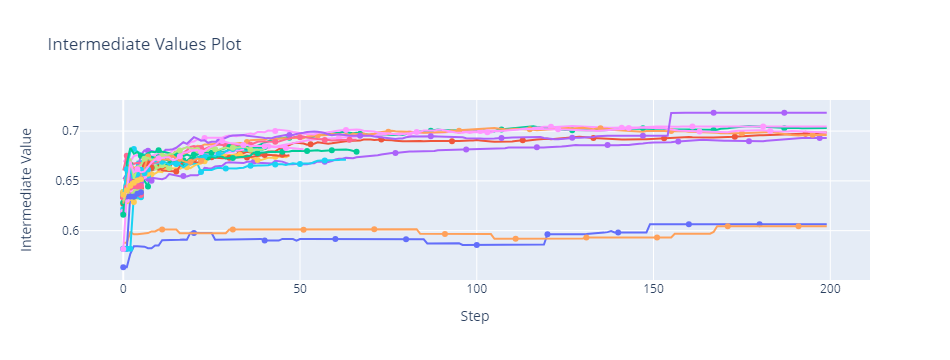

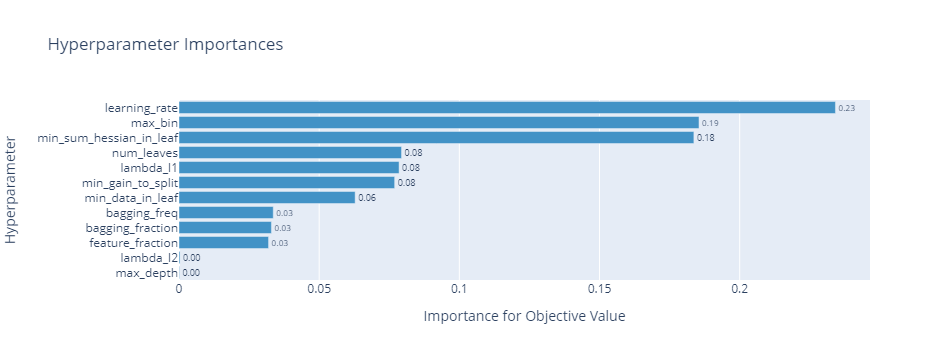

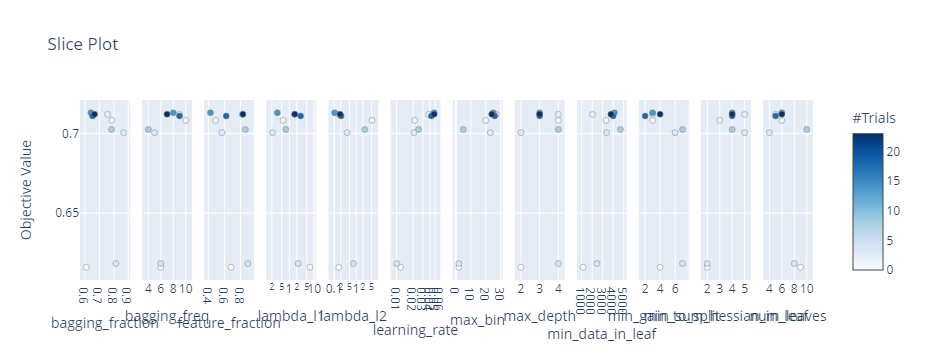

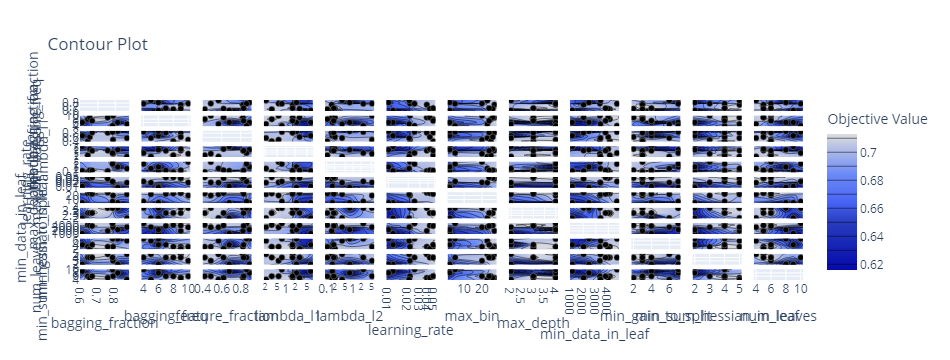

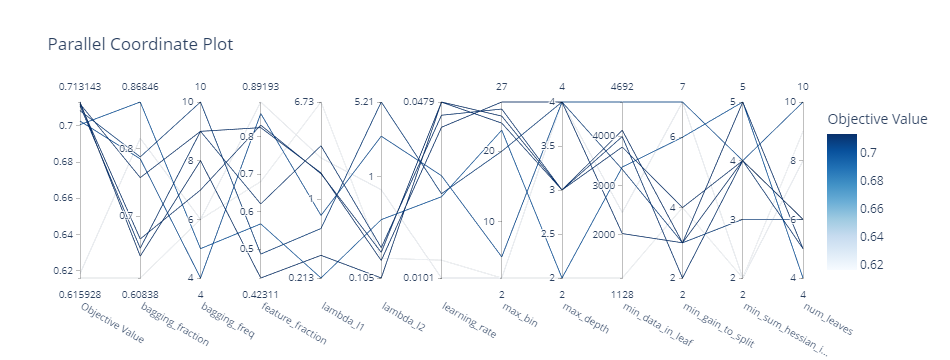

In [72]:
# opt可视化分析
fig = optuna.visualization.plot_intermediate_values(study)
py.plot(fig, filename='intermediate_values.html')
fig.show()

fig = optuna.visualization.plot_param_importances(study)
py.plot(fig, filename='param_importances.html')
fig.show()

fig = optuna.visualization.plot_slice(study)
py.plot(fig, filename='slice.html')
fig.show()

fig = optuna.visualization.plot_contour(study)
py.plot(fig, filename='contour.html')
fig.show()

fig = optuna.visualization.plot_parallel_coordinate(study)
py.plot(fig, filename='parallel_coordinate.html')
fig.show()

In [15]:
# 第一轮调参最优组合
# params = \
# {'num_leaves': 9,
#  'learning_rate': 0.05919424138017577,
#  'lambda_l1': 1.023489342651961,
#  'lambda_l2': 0.1657718230796538,
#  'bagging_freq': 7,
#  'bagging_fraction': 0.952081790986627,
#  'feature_fraction': 0.7064938520312755,
#  'max_depth': 4,
#  'min_sum_hessian_in_leaf': 5,
#  'min_gain_to_split': 5,
#  'min_data_in_leaf': 1507,
#  'max_bin': 6,
#  'seed': 42,
#  'objective': 'binary',
#  'boosting': 'gbdt',
#  'metric': 'auc',
#  'verbosity': -1}

# 第二轮调参最优组合
# {'num_leaves': 6,
#  'learning_rate': 0.04794861332186522,
#  'lambda_l1': 0.3321265818617803,
#  'lambda_l2': 0.10529618699515002,
#  'bagging_freq': 8,
#  'bagging_fraction': 0.6407219071655347,
#  'feature_fraction': 0.4231148996070733,
#  'max_depth': 3,
#  'min_sum_hessian_in_leaf': 4,
#  'min_gain_to_split': 3,
#  'min_data_in_leaf': 4120,
#  'max_bin': 25,
#  'seed': 42,
#  'objective': 'binary',
#  'boosting': 'gbdt',
#  'metric': 'auc',
#  'verbosity': -1}

# **三、重新建模**

In [98]:
# 将学习对象的最优参数赋值给params
params = study.best_params
params

{'num_leaves': 6,
 'learning_rate': 0.04794861332186522,
 'lambda_l1': 0.3321265818617803,
 'lambda_l2': 0.10529618699515002,
 'bagging_freq': 8,
 'bagging_fraction': 0.6407219071655347,
 'feature_fraction': 0.4231148996070733,
 'max_depth': 3,
 'min_sum_hessian_in_leaf': 4,
 'min_gain_to_split': 3,
 'min_data_in_leaf': 4120,
 'max_bin': 25}

In [39]:
params['seed'] = 42
params['objective'] = 'binary'
params['boosting'] = "gbdt"
params['metric'] = 'auc'
params['verbosity'] = -1
early_stop = 100
verbose_eval = 20
num_rounds = 200

# 对原数据进行切分
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
print(X_train.shape)
print(X_valid.shape)

d_train = lgb.Dataset(X_train, label=y_train, categorical_feature=None)
d_valid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=None)
watchlist = [d_train, d_valid]

print('training LGB:')
model = lgb.train(params,
                  train_set=d_train,
                  num_boost_round=num_rounds,
                  valid_sets=watchlist,
                  verbose_eval=verbose_eval,
                  early_stopping_rounds=early_stop)
print('best iteration %s' %model.best_iteration)

# 预测
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)

print('best_score', model.best_score)

(105623, 259)
(26406, 259)
training LGB:
Training until validation scores don't improve for 100 rounds
[20]	training's auc: 0.73632	valid_1's auc: 0.70343
[40]	training's auc: 0.747095	valid_1's auc: 0.710124
[60]	training's auc: 0.752276	valid_1's auc: 0.712541
[80]	training's auc: 0.752418	valid_1's auc: 0.712392
[100]	training's auc: 0.752418	valid_1's auc: 0.712392
[120]	training's auc: 0.752418	valid_1's auc: 0.712392
[140]	training's auc: 0.752418	valid_1's auc: 0.712392
Early stopping, best iteration is:
[50]	training's auc: 0.750108	valid_1's auc: 0.713588
best iteration 50
best_score defaultdict(<class 'collections.OrderedDict'>, {'training': OrderedDict([('auc', 0.7501077662343104)]), 'valid_1': OrderedDict([('auc', 0.71358751689599)])})


In [40]:
# 通过模型对象预测结果
def pred(X_test, models):
    y_test_pred_total = np.zeros(X_test.shape[0])
    for i, model in enumerate(models):
        print(f'predicting {i}-th model')
        y_pred_test = model.predict(X_test, num_iteration=model.best_iteration)
        y_test_pred_total += y_pred_test
    y_test_pred_total /= len(models)
    return y_test_pred_total

# 可视化特征重要性
def plot_feature_importance(model,features):
    importance_df = pd.DataFrame(model.feature_importance(),
                                 index=features,
                                 columns=['importance']).sort_values('importance').sort_values(by='importance',ascending=False).head(50)
    fig, ax = plt.subplots(figsize=(10, 15))
    importance_df.plot.barh(ax=ax)
    fig.show()

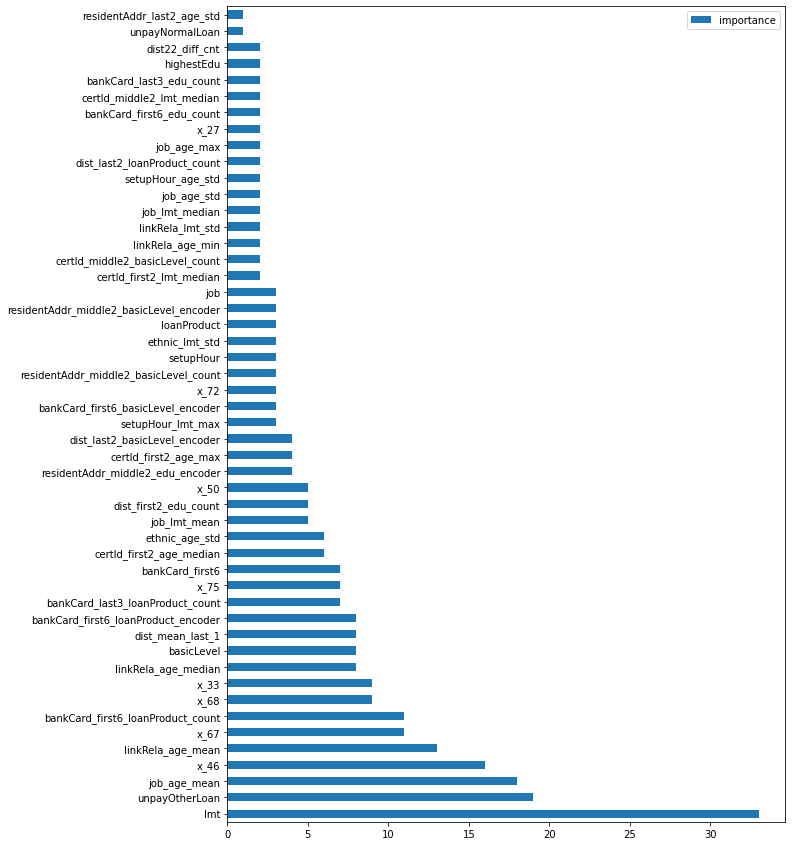

In [41]:
# 展示排名前50的特征重要性
plot_feature_importance(model, features)